In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/fashion_products.csv')

In [4]:
pd.set_option('display.max_columns', None) #displays all columns henceforth

In [5]:
df

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M
...,...,...,...,...,...,...,...,...,...
995,20,996,Shoes,Zara,Women's Fashion,55,1.620081,Black,M
996,42,997,Sweater,Nike,Kids' Fashion,13,1.544464,Green,L
997,9,998,Sweater,Zara,Men's Fashion,47,3.961913,White,L
998,8,999,T-shirt,Zara,Women's Fashion,68,3.089722,Blue,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Price         1000 non-null   int64  
 6   Rating        1000 non-null   float64
 7   Color         1000 non-null   object 
 8   Size          1000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [7]:
df.isnull().sum()

,0
User ID,0
Product ID,0
Product Name,0
Brand,0
Category,0
Price,0
Rating,0
Color,0
Size,0


In [8]:
df[df.duplicated()]

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size


In [19]:
df['Product Name'].unique()

array(['Dress', 'Shoes', 'T-shirt', 'Jeans', 'Sweater'], dtype=object)

In [20]:
df['User ID'].nunique()

100

In [21]:
df['Brand'].unique()

array(['Adidas', 'H&M', 'Zara', 'Gucci', 'Nike'], dtype=object)

In [22]:
df['Category'].unique()

array(["Men's Fashion", "Women's Fashion", "Kids' Fashion"], dtype=object)

In [24]:
df['Rating'].nunique()

1000

In [25]:
df['Color'].unique()

array(['Black', 'Yellow', 'White', 'Blue', 'Green', 'Red'], dtype=object)

In [26]:
df['Size'].unique()

array(['XL', 'L', 'S', 'M'], dtype=object)

In [27]:
for i in df.select_dtypes(include=["object"]).columns:
  print(i)

Product Name
Brand
Category
Color
Size


In [28]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [29]:
for i in df.select_dtypes(include=["object"]).columns:
  df[i]= label.fit_transform(df[i])

In [30]:
df

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,0,0,1,40,1.043159,0,3
1,97,2,2,2,2,82,4.026416,0,0
2,25,3,0,0,2,44,3.337938,5,3
3,57,4,2,4,1,23,1.049523,4,2
4,79,5,4,0,1,79,4.302773,0,1
...,...,...,...,...,...,...,...,...,...
995,20,996,2,4,2,55,1.620081,0,1
996,42,997,3,3,0,13,1.544464,2,0
997,9,998,3,4,1,47,3.961913,4,0
998,8,999,4,4,2,68,3.089722,1,2


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   int64  
 3   Brand         1000 non-null   int64  
 4   Category      1000 non-null   int64  
 5   Price         1000 non-null   int64  
 6   Rating        1000 non-null   float64
 7   Color         1000 non-null   int64  
 8   Size          1000 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 70.4 KB


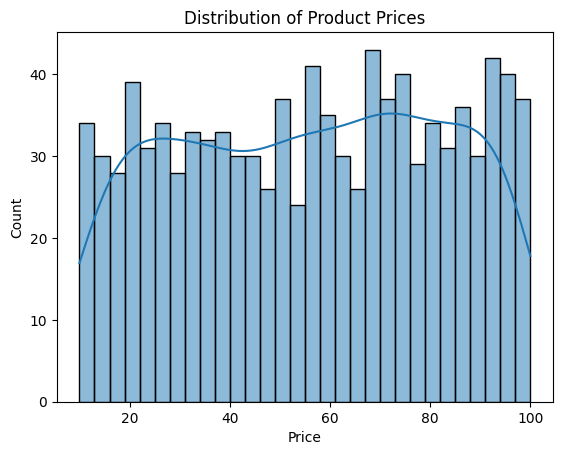

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
# distribution of product prices

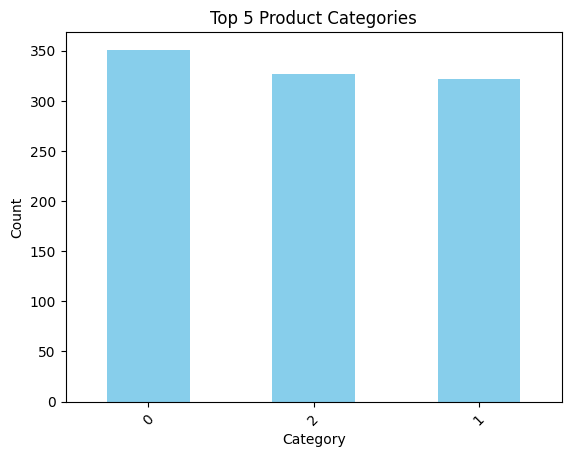

In [33]:
df['Category'].value_counts().head(5).plot(kind='bar', color='skyblue')
plt.title("Top 5 Product Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
# the top 5 most frequent product categories

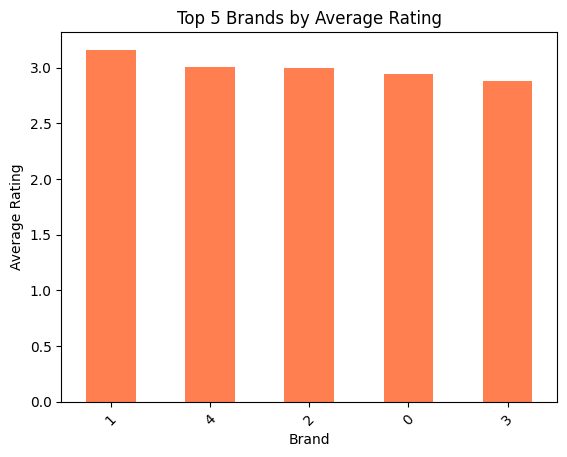

In [34]:
df.groupby('Brand')['Rating'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='coral')
plt.title("Top 5 Brands by Average Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()
# brands having the highest average ratings

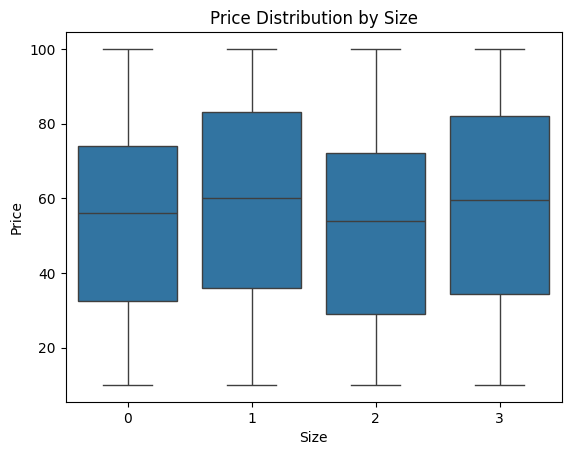

In [35]:
sns.boxplot(x='Size', y='Price', data=df)
plt.title("Price Distribution by Size")
plt.show()
# price varying by product size

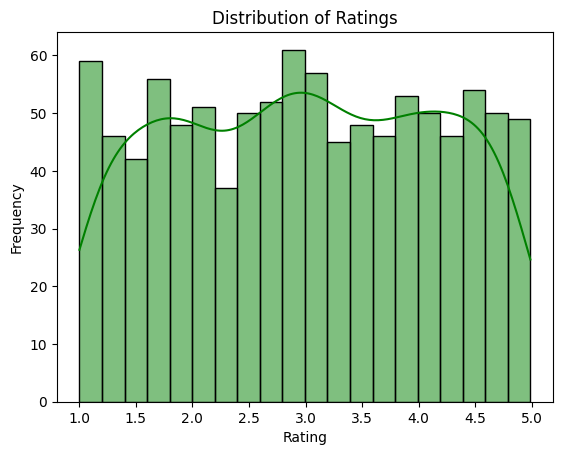

In [36]:
sns.histplot(df['Rating'], bins=20, kde=True, color='green')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()
# the rating distribution across the dataset

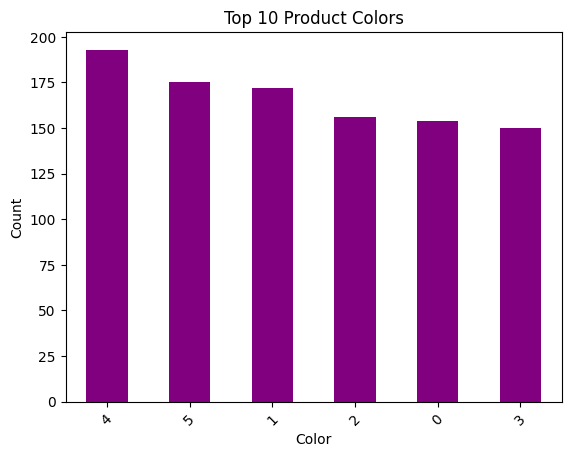

In [37]:
df['Color'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title("Top 10 Product Colors")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
# the most popular product colors

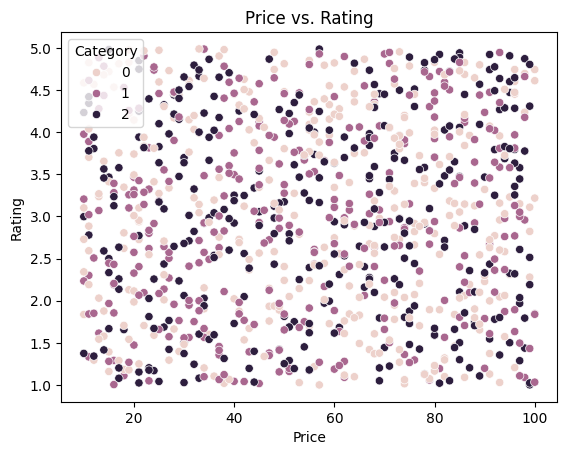

In [38]:
sns.scatterplot(x='Price', y='Rating', data=df, hue='Category')
plt.title("Price vs. Rating")
plt.show()
# the relationship between price and rating

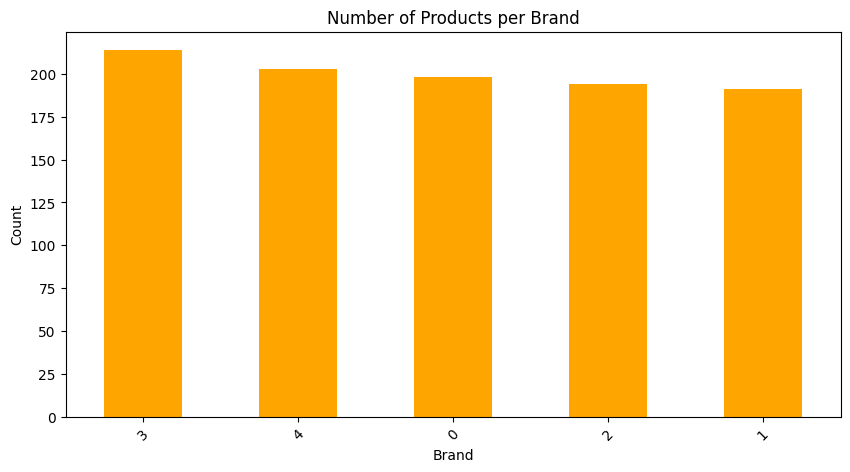

In [39]:
df['Brand'].value_counts().plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Number of Products per Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
# products offered per brand

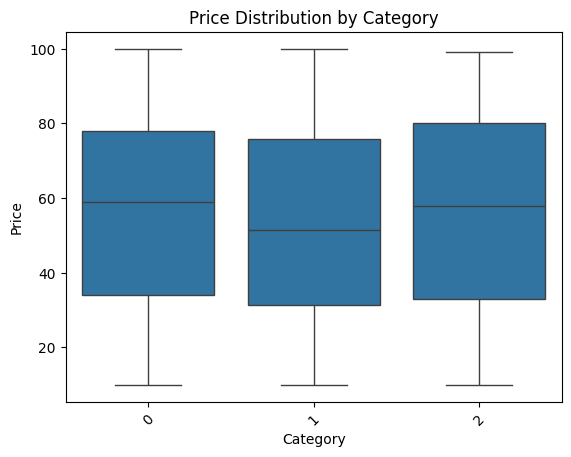

In [40]:
sns.boxplot(x='Category', y='Price', data=df)
plt.title("Price Distribution by Category")
plt.xticks(rotation=45)
plt.show()
# the price range for each product category

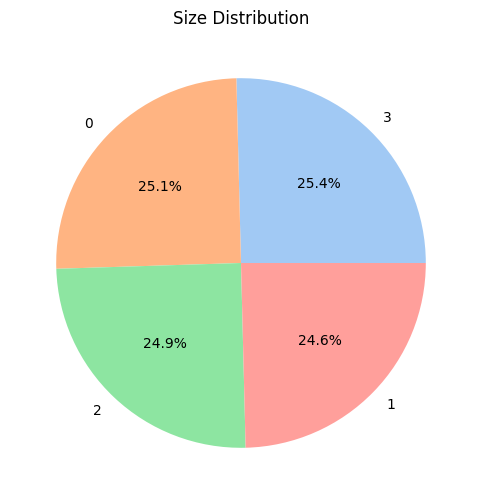

In [41]:
df['Size'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=sns.color_palette('pastel'))
plt.title("Size Distribution")
plt.ylabel("")
plt.show()
# sizes that are most frequently available

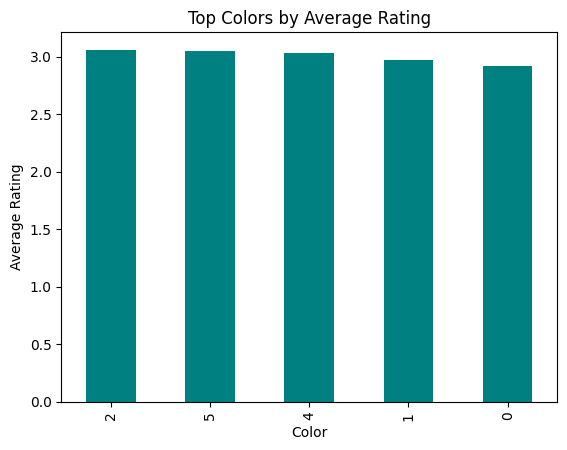

In [42]:
df.groupby('Color')['Rating'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='teal')
plt.title("Top Colors by Average Rating")
plt.ylabel("Average Rating")
plt.show()
# color with the highest average rating

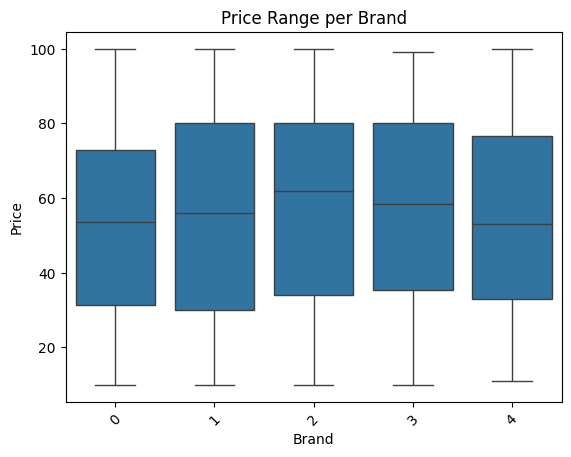

In [43]:
sns.boxplot(x='Brand', y='Price', data=df)
plt.title("Price Range per Brand")
plt.xticks(rotation=45)
plt.show()
# Do different brands focus on different price ranges?

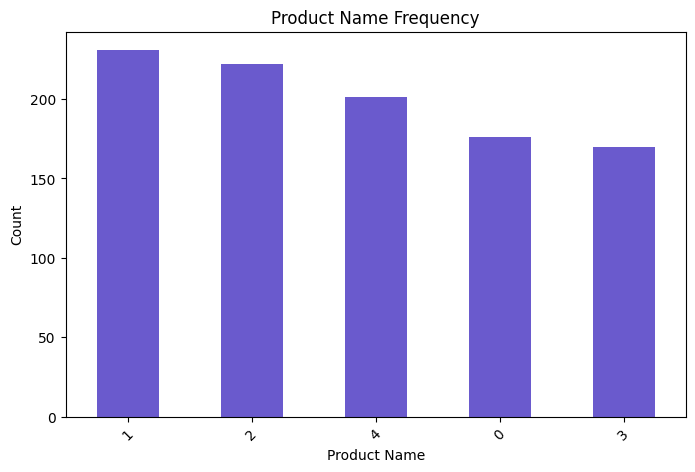

In [44]:
df['Product Name'].value_counts().plot(kind='bar', figsize=(8,5), color='slateblue')
plt.title("Product Name Frequency")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
# the distribution of product types (Product Name)

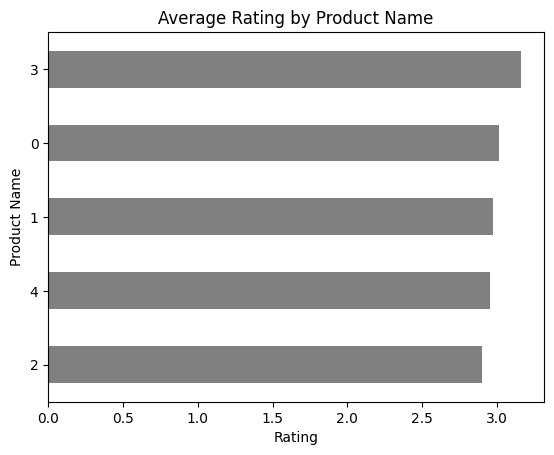

In [45]:
df.groupby('Product Name')['Rating'].mean().sort_values().plot(kind='barh', color='gray')
plt.title("Average Rating by Product Name")
plt.xlabel("Rating")
plt.show()
# the average rating per product name

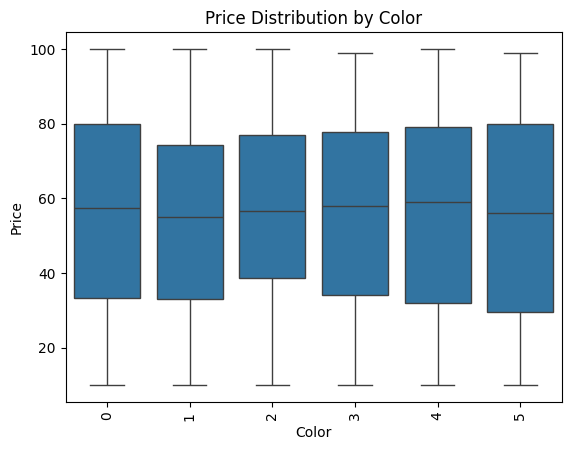

In [46]:
sns.boxplot(x='Color', y='Price', data=df)
plt.title("Price Distribution by Color")
plt.xticks(rotation=90)
plt.show()

# the distribution of product prices per color